### NDK Forward-Modeling Calculator for LMT Interferometry

*Author: Eric C. Thompson*

[https://orcid.org/0009-0001-4127-1742](https://orcid.org/0009-0001-4127-1742)



This Python script implements a transparent forward-model for estimating irreducible stochastic phase diffusion within the Null-Directional Kinematics (NDK) framework. It is intended for Large Momentum Transfer (LMT) atom interferometers such as MAGIS-100 and the Stanford 10 m platform.

**Fixed Theory-Side Parameters**

To keep the calculation rigid and avoid phenomenological curve-fitting, the theory-side calibration parameters are not swept.
- The internal geometry parameters (`chi`, `eta`) are held fixed at order unity.
- The dimensionless threshold is fixed to `I_star_over_A = 3.28`, matching the benchmark adopted in the NDK supermassive black hole saturation analysis.

This setup allows experimental sequence parameters to vary (`T`, `n`, `k_eff`, coherence scale inputs) while keeping the underlying NDK bridge assumptions fixed.

**Capabilities**

Given a chosen interferometer configuration, the calculator evaluates:
1. The accumulated transport burden (`D_tr`) on the local substrate.
2. The predicted non-refocusable residual visibility (`V_res`) from background directional strain.
3. Diagnostic boundary conditions, such as the pre-split coherence length (`lambda_coh0`) required to remain below a specified dephasing target.

The code below computes the physical bounds used in the accompanying scaling plots.

In [5]:
import math
from dataclasses import dataclass

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0                      # m/s
HBAR = 1.054_571_817e-34              # J*s
H = 6.626_070_15e-34                  # J*s
K_B = 1.380_649e-23                   # J/K
L_PLANCK = 1.616_255e-35              # m

# Example atomic masses (kg)
MASS_RB87 = 1.443_160_60e-25
MASS_SR88 = 1.460_0e-25   # rough convenience value

@dataclass
class FixedCellInputs:
    # Experimental geometry
    T: float                           # interrogation time [s]
    n: float                           # effective LMT order
    k_eff: float                       # effective wavevector [1/m]
    w_coh: float                       # coherence-support width [m]

    # Theory / bridge parameters
    I_star_over_A: float = 3.28        # cosmological threshold calibration
    chi: float = 1.0                   # order-one burden factor
    eta: float = 1.0                   # order-one cell-size factor

    # Fixed pre-split coherence scale
    lambda_coh0: float | None = None   # [m], if known directly

def thermal_de_broglie_wavelength(mass: float, temperature_K: float) -> float:
    """
    Thermal de Broglie wavelength:
        lambda_th = h / sqrt(2*pi*m*k_B*T)
    """
    return H / math.sqrt(2.0 * math.pi * mass * K_B * temperature_K)

def burden_Dtr(T: float, n: float, k_eff: float,
               I_star_over_A: float = 3.28, chi: float = 1.0) -> float:
    """
    Dimensionless transport burden:
        D_tr = pi * chi * (I_*/A) * c * l_P * T * n^2 * k_eff^2
    """
    return math.pi * chi * I_star_over_A * C * L_PLANCK * T * n**2 * k_eff**2

def fixed_cell_area(lambda_coh0: float, eta: float = 1.0) -> float:
    """
    Fixed operational cell:
        A_* = eta * lambda_coh0^2
    """
    return eta * lambda_coh0**2

def coherence_support_area(w_coh: float) -> float:
    """
    Coherence-support area:
        A_coh = pi * w_coh^2
    """
    return math.pi * w_coh**2

def xi_bridge_fixed_cell(inputs: FixedCellInputs, I_local: float = 1.4e-9) -> float:
    """
    Effective xi implied by the fixed-cell bridge:
        xi = chi * (I_*/A)/I_local * (A_coh/A_*)
    """
    if inputs.lambda_coh0 is None:
        raise ValueError("Set lambda_coh0 first.")
    A_coh = coherence_support_area(inputs.w_coh)
    A_star = fixed_cell_area(inputs.lambda_coh0, inputs.eta)
    return inputs.chi * (inputs.I_star_over_A / I_local) * (A_coh / A_star)

def predicted_dephasing(inputs: FixedCellInputs) -> float:
    """
    Predicted residual dephasing:
        D_pred = (pi*chi/eta) * (I_*/A) * c*l_P*T*n^2*k_eff^2 * (w_coh/lambda_coh0)^2
    """
    if inputs.lambda_coh0 is None:
        raise ValueError("Set lambda_coh0 first.")
    pref = (math.pi * inputs.chi / inputs.eta) * inputs.I_star_over_A
    geom = C * L_PLANCK * inputs.T * inputs.n**2 * inputs.k_eff**2
    ratio = (inputs.w_coh / inputs.lambda_coh0)**2
    return pref * geom * ratio

def predicted_visibility(inputs: FixedCellInputs) -> float:
    """
    Residual visibility:
        V_res = exp(-D_pred)
    """
    D = predicted_dephasing(inputs)
    return math.exp(-D)

def required_lambda_coh0_for_target_D(inputs: FixedCellInputs, D_target: float) -> float:
    """
    Solve for the pre-split coherence length needed to hit a target dephasing:
        lambda_coh0 = w_coh * sqrt[(pi*chi/eta)*(I_*/A)*c*l_P*T*n^2*k_eff^2 / D_target]
    """
    inside = ((math.pi * inputs.chi / inputs.eta)
              * inputs.I_star_over_A
              * C * L_PLANCK * inputs.T * inputs.n**2 * inputs.k_eff**2
              / D_target)
    return inputs.w_coh * math.sqrt(inside)

def required_eta_for_target_D(inputs: FixedCellInputs, D_target: float) -> float:
    """
    If lambda_coh0 is fixed independently, solve for eta required to hit D_target.
    """
    if inputs.lambda_coh0 is None:
        raise ValueError("Set lambda_coh0 first.")
    numerator = (math.pi * inputs.chi
                 * inputs.I_star_over_A
                 * C * L_PLANCK * inputs.T * inputs.n**2 * inputs.k_eff**2
                 * (inputs.w_coh / inputs.lambda_coh0)**2)
    return numerator / D_target

def summary(inputs: FixedCellInputs, D_targets=(1e-3, 1e-2), I_local: float = 1.4e-9):
    print("=== NDK forward-model calculator (fixed-cell bridge) ===")
    print(f"T                = {inputs.T:.3g} s")
    print(f"n                = {inputs.n:.3g}")
    print(f"k_eff            = {inputs.k_eff:.3g} 1/m")
    print(f"w_coh            = {inputs.w_coh:.3g} m")
    print(f"I_star_over_A    = {inputs.I_star_over_A:.3g}")
    print(f"chi              = {inputs.chi:.3g}")
    print(f"eta              = {inputs.eta:.3g}")

    if inputs.lambda_coh0 is not None:
        print(f"lambda_coh0      = {inputs.lambda_coh0:.3g} m")
        print(f"A_star           = {fixed_cell_area(inputs.lambda_coh0, inputs.eta):.3e} m^2")
        print(f"A_coh            = {coherence_support_area(inputs.w_coh):.3e} m^2")
        print(f"D_tr             = {burden_Dtr(inputs.T, inputs.n, inputs.k_eff, inputs.I_star_over_A, inputs.chi):.3e}")
        print(f"xi_bridge        = {xi_bridge_fixed_cell(inputs, I_local):.3e}")
        D_pred = predicted_dephasing(inputs)
        V_pred = predicted_visibility(inputs)
        print(f"D_pred           = {D_pred:.3e}")
        print(f"V_res            = {V_pred:.6g}")

    print("\n--- Required lambda_coh0 for target dephasing ---")
    for D_t in D_targets:
        lam_req = required_lambda_coh0_for_target_D(inputs, D_t)
        print(f"D_target={D_t:.1e}  ->  lambda_coh0_required = {lam_req*1e6:.3f} microns")

    if inputs.lambda_coh0 is not None:
        print("\n--- Required eta for target dephasing ---")
        for D_t in D_targets:
            eta_req = required_eta_for_target_D(inputs, D_t)
            print(f"D_target={D_t:.1e}  ->  eta_required = {eta_req:.3e}")

# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Example 1: direct coherence length input
    stanford_like = FixedCellInputs(
        T=1.4,
        n=100.0,
        k_eff=1.0e7,
        w_coh=100e-6,
        I_star_over_A=3.28,
        chi=1.0,
        eta=1.0,
        lambda_coh0=1.0e-6,   # e.g. 1 micron coherence scale
    )
    summary(stanford_like)

    print("\n" + "="*60 + "\n")

    # Example 2: derive coherence length from thermal de Broglie wavelength
    T_atom = 100e-9  # 100 nK
    lambda_th_rb = thermal_de_broglie_wavelength(MASS_RB87, T_atom)

    magis_like = FixedCellInputs(
        T=3.0,
        n=1000.0,
        k_eff=1.0e7,
        w_coh=100e-6,
        I_star_over_A=3.28,
        chi=1.0,
        eta=1.0,
        lambda_coh0=lambda_th_rb,
    )
    summary(magis_like)

=== NDK forward-model calculator (fixed-cell bridge) ===
T                = 1.4 s
n                = 100
k_eff            = 1e+07 1/m
w_coh            = 0.0001 m
I_star_over_A    = 3.28
chi              = 1
eta              = 1
lambda_coh0      = 1e-06 m
A_star           = 1.000e-12 m^2
A_coh            = 3.142e-08 m^2
D_tr             = 6.990e-08
xi_bridge        = 7.360e+13
D_pred           = 6.990e-04
V_res            = 0.999301

--- Required lambda_coh0 for target dephasing ---
D_target=1.0e-03  ->  lambda_coh0_required = 0.836 microns
D_target=1.0e-02  ->  lambda_coh0_required = 0.264 microns

--- Required eta for target dephasing ---
D_target=1.0e-03  ->  eta_required = 6.990e-01
D_target=1.0e-02  ->  eta_required = 6.990e-02


=== NDK forward-model calculator (fixed-cell bridge) ===
T                = 3 s
n                = 1e+03
k_eff            = 1e+07 1/m
w_coh            = 0.0001 m
I_star_over_A    = 3.28
chi              = 1
eta              = 1
lambda_coh0      = 5.92e-07 

### Scaling Plot for the Fixed-Cell NDK Forward Model (`ndk_scaling_plot.py`)

While the forward calculator evaluates specific point predictions, this script visualizes the broader scaling behavior across the operating range relevant to modern LMT atom interferometers.

Rather than plotting a single parameter choice, the script sweeps representative ranges for the local microscopic inputs — coherence-support width $w_{\rm coh}$, pre-split coherence length $\lambda_{\rm coh,0}$, and order-unity geometric factors $\chi$ and $\eta$ — and displays the **median** together with the **interquartile range (25th to 75th percentile)** of the resulting predicted dephasing.

The cosmological threshold is held fixed at $\mathcal{I}_*/A = 3.28$ across the full sweep so that the plotted variation reflects only the local bridge parameters, not retuning of the global calibration.

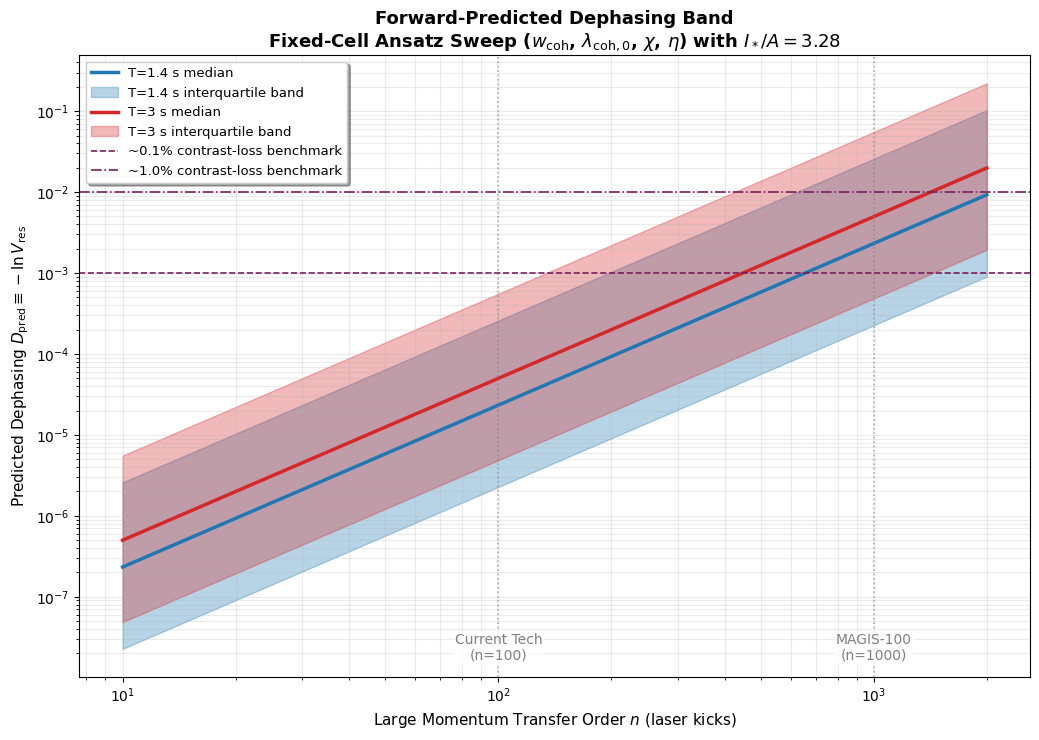

In [7]:
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Constants (SI)
# -----------------------------
C = 299_792_458.0
L_PLANCK = 1.616_255e-35

def predicted_dephasing(
    T,
    n,
    k_eff,
    w_coh,
    lambda_coh0,
    I_star_over_A=3.28,
    chi=1.0,
    eta=1.0
):
    """
    Fixed-cell forward model:
        D_pred = (pi*chi/eta) * (I_*/A) * c*l_P*T*n^2*k_eff^2 * (w_coh/lambda_coh0)^2
    """
    pref = (math.pi * chi / eta) * I_star_over_A
    geom = C * L_PLANCK * T * n**2 * k_eff**2
    ratio = (w_coh / lambda_coh0)**2
    return pref * geom * ratio


# -----------------------------
# Sweep ranges for the fixed-cell forward model
# -----------------------------
w_coh_values = [10e-6, 30e-6, 100e-6]              # 10, 30, 100 microns
lambda_coh0_values = [0.3e-6, 1e-6, 3e-6, 10e-6]  # 0.3, 1, 3, 10 microns
chi_values = [0.1, 1.0, 10.0]
eta_values = [0.3, 1.0, 3.0]
I_star_over_A_values = [3.28]                      # Fixed calibrated value
k_eff_values = [1.0e7]

# Representative time scales
T_values = [1.4, 3.0]  # Stanford-like and MAGIS-like

# Color palette
COLOR_MAP = {
    1.4: "#1f77b4",  # blue
    3.0: "#d62728",  # red
}
THRESHOLD_COLOR = "#7A1F5C"

# Plot domain
n_vals = np.logspace(1, 3.3, 300)  # 10 to ~2000

# Styling
plt.rcParams["font.family"] = "sans-serif"
fig, ax = plt.subplots(figsize=(10.5, 7.5))

# Custom legend handles
legend_handles = []

for T in T_values:
    p25s, meds, p75s = [], [], []

    for n in n_vals:
        vals = []
        for w_coh, lambda_coh0, chi, eta, I_star_over_A, k_eff in itertools.product(
            w_coh_values,
            lambda_coh0_values,
            chi_values,
            eta_values,
            I_star_over_A_values,
            k_eff_values
        ):
            vals.append(
                predicted_dephasing(
                    T=T,
                    n=float(n),
                    k_eff=k_eff,
                    w_coh=w_coh,
                    lambda_coh0=lambda_coh0,
                    I_star_over_A=I_star_over_A,
                    chi=chi,
                    eta=eta
                )
            )

        arr = np.array(vals)
        p25s.append(np.percentile(arr, 25))
        meds.append(np.median(arr))
        p75s.append(np.percentile(arr, 75))

    p25s = np.array(p25s)
    meds = np.array(meds)
    p75s = np.array(p75s)

    color = COLOR_MAP[T]

    line, = ax.plot(
        n_vals, meds,
        linewidth=2.5,
        color=color,
        label=f"T={T:g} s median"
    )

    ax.fill_between(
        n_vals, p25s, p75s,
        alpha=0.32,
        color=color
    )

    iqr_patch = mpatches.Patch(
        color=color,
        alpha=0.32,
        label=f"T={T:g} s interquartile band"
    )

    legend_handles.extend([line, iqr_patch])

# Reference vertical lines
ax.axvline(100, linestyle=":", linewidth=1.2, color="gray", alpha=0.6)
ax.axvline(1000, linestyle=":", linewidth=1.2, color="gray", alpha=0.6)

# Threshold lines
hline1 = ax.axhline(
    1e-3,
    linestyle="--",
    linewidth=1.2,
    color=THRESHOLD_COLOR,
    label="~0.1% contrast-loss benchmark"
)
hline2 = ax.axhline(
    1e-2,
    linestyle="-.",
    linewidth=1.2,
    color=THRESHOLD_COLOR,
    label="~1.0% contrast-loss benchmark"
)
legend_handles.extend([hline1, hline2])

# Axes
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Large Momentum Transfer Order $n$ (laser kicks)", fontsize=11)
ax.set_ylabel(r"Predicted Dephasing $D_{\rm pred} \equiv -\ln V_{\rm res}$", fontsize=11)
ax.set_title(
    "Forward-Predicted Dephasing Band\n"
    r"Fixed-Cell Ansatz Sweep ($w_{\rm coh}$, $\lambda_{\rm coh,0}$, $\chi$, $\eta$) with $I_*/A=3.28$",
    fontsize=13,
    fontweight="bold"
)

# Grid
ax.grid(True, which="both", alpha=0.25)

# Annotations
TEXT_BBOX = dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5)
ymin, ymax = ax.get_ylim()

ax.text(
    100, ymin * 1.5,
    "Current Tech\n(n=100)",
    ha="center", va="bottom",
    fontsize=10, color="gray",
    bbox=TEXT_BBOX
)

ax.text(
    1000, ymin * 1.5,
    "MAGIS-100\n(n=1000)",
    ha="center", va="bottom",
    fontsize=10, color="gray",
    bbox=TEXT_BBOX
)

# Legend
ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=9.5,
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()

# Optional save:
# plt.savefig("ndk_fixed_cell_dephasing_band_IstarA_3p28.png", dpi=300, bbox_inches="tight")

**Figure 1: Forward-predicted stochastic dephasing vs. LMT order ($n$).** The shaded bands show the interquartile range of predicted non-refocusable dephasing for interrogation times $T=1.4$ s (Stanford-like) and $T=3.0$ s (MAGIS-like), with solid curves marking the median across the parameter sweep. The figure illustrates the underlying $n^2$ scaling of the fixed-cell NDK forward model: at current LMT scales ($n \sim 100$), the predicted intrinsic contribution remains strongly suppressed, while toward higher momentum transfer ($n \sim 10^3$) the upper portion of the predicted band approaches and, in the MAGIS-like case, enters the 1% contrast-loss regime. In that sense, the plot identifies a concrete experimental window in which substrate-limited dephasing would become increasingly difficult to hide beneath conventional noise sources.